# 08 · Digital Demand Signals & Tourism Demand EDA

## Business question

**Can digital demand signals anticipate Spanish outbound tourism demand to support airline seat allocation decisions?**

Travel agencies and tour operators must commit to airline seat allotments 11-12 months in advance. The lack of forecasts can result in unsold seats (financial loss) or insufficient capacity (lost revenue and customer dissatisfaction). This notebook evaluates whether two publicly available digital signals can complement official statistics to improve forecast accuracy.

## Signals evaluated

| Signal | Source | Type |
|---|---|---|
| `monthly_searches` | DataForSEO Google Ads API | Absolute monthly search volume |
| `trend_index` | Google Trends (Pytrends) | Relative normalized interest (0–100) |

Both signals are constructed using the prefix `"viaje a [destination]"` to capture agency-mediated travel intent.

## Analytical objectives

1. Quantify search-demand alignment across destinations
2. Identify lead-time properties of search signals
3. Determine for which destinations digital signals are operationally useful
4. Document methodological limitations and provide actionable recommendations

## Reference data

Tourism demand is measured using INE Experimental Tourism Mobility Dataset (2019–2025), which captures outbound trips via anonymized mobile phone positioning, corrected to 100% of the population via CNMC factors.

---
# PART A — Tourism Demand Structure

## 1. Imports

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import pycountry
from pathlib import Path
import pycountry
from scipy import stats
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
import warnings; warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load datasets

In [69]:
DATA_PATH = Path("../data/processed")

# Full outbound dataset (all destinations, all years)
df_spain = pd.read_parquet(
    DATA_PATH / "07_master_demand.parquet"
)

# Strategic subset: medium/long-haul, include_in_analysis == True
df_non_europe = pd.read_parquet(
    DATA_PATH / "07_demand_non_europe.parquet"
)

# Commercial subset: + agency_profile in medium, high
df_commercial = pd.read_parquet(
    DATA_PATH / "07_demand_commercial_destinations.parquet"
)

# Commercial subset excluding USA
df_commercial_no_usa = pd.read_parquet(
    DATA_PATH / "07_demand_commercial_non_usa_eu.parquet"
)

# Aggregated signals (for zero-value analysis)
df_trends_agg = pd.read_parquet(
    DATA_PATH / "07_trends_agg.parquet"
)

df_monthly_searches_agg = pd.read_parquet(
    DATA_PATH / "07_monthly_searches_agg.parquet"
)

print(f"df_spain:              {df_spain.shape}")
print(f"df_non_europe:         {df_non_europe.shape}")
print(f"df_commercial:         {df_commercial.shape}")
print(f"df_commercial_no_usa:  {df_commercial_no_usa.shape}")

df_spain:              (8044, 19)
df_non_europe:         (5157, 19)
df_commercial:         (2945, 19)
df_commercial_no_usa:  (2864, 19)


In [70]:
# Geo parquets
GEO_PATH = Path("../data/interim/geo")

# Carrega el dataset geo complet
df_geo_all = pd.read_parquet(
    GEO_PATH / "07_spanish_all_countries_geo.parquet"
)


In [71]:
print(f"df_geo_all  {df_geo_all.shape}")

df_geo_all  (711851, 34)


## 3. Analytical scope

The objective of this project is not to model total outbound tourism demand indiscriminately, but to focus on destinations strategically relevant for travel agencies and organized tourism operators.

Most short-haul European destinations were excluded from the strategic subset because they typically involve:
- independent travel and road-based mobility,
- short city-break patterns,
- weaker dependence on travel agencies.

A limited number of European exceptions (Norway, Finland, Iceland) were preserved due to their alignment with premium, experience-oriented and agency-driven travel demand.

> **Design decision:** The `"viaje a"` prefix structure was selected as a pragmatic proxy for destination-oriented travel planning. However, the extent to which it accurately captures actual traveler search behavior remains an important methodological limitation of the project.

Four analytical subsets are used throughout this notebook:

| Dataset | Description |
|---|---|
| `df_spain` | All destinations, all trips |
| `df_non_europe` | Extra-European + selected European (NO, FI, IS) |
| `df_commercial` | `df_non_europe` filtered to `agency_profile` = medium/high |
| `df_commercial_no_usa` | `df_commercial` excluding USA (structural outlier) |

> **Note on Morocco:** Excluded from the strategic subset due to its high  > VFR and migration-related mobility component, which is not useful nor representative of organized leisure tourism demand.

> **Note on USA:** Excluded from the most restrictive subset (`df_commercial_no_usa`) 
> due to structural complexity, combining leisure tourism, VFR travel, student mobility and business trips in proportions that cannot be disaggregated with the available data sources. The ETR survey does not provide country-level decomposition within the Americas region.

### Empirical basis for subset design

INE's Encuesta de Turismo de Residentes confirms the structural differences across regions. Only 38% of Spanish trips to América are leisure-motivated, compared to 67% for Europe — the rest is VFR, business, and other non-tourism travel. This asymmetry justifies why correlations between search signals and INE mobility data should be evaluated on the strategic subset, where both signals are more likely to capture the same traveler population.

This evidence supports the central methodological hypothesis of the project: digital search signals are expected to perform better when both the observed demand and the search behavior originate from similar traveler segments.

<img src="../outputs/figures/all_destinations_subset_legend_horizontal.svg" width="900">

---

## 4. Strategic subset coverage

In [72]:
all_destinations     = df_spain["destination"].nunique()
relevant_destinations = df_commercial["destination"].nunique()
total_tourists_all   = df_spain["total_tourists"].sum()
total_tourists_rel   = df_commercial["total_tourists"].sum()

print(f"Total destinations (all):      {all_destinations}")
print(f"Strategic destinations:        {relevant_destinations} ({relevant_destinations/all_destinations:.1%})")
print(f"Tourism demand coverage:       {total_tourists_rel/total_tourists_all:.1%} of total volume")


Total destinations (all):      155
Strategic destinations:        46 (29.7%)
Tourism demand coverage:       5.0% of total volume


- Long-haul destinations represent only 5% of total outbound volume but remain strategically relevant due to higher average spending, agency dependency and operational complexity.

- Within leisure travel, agency-mediated trips (travel packages) represent 45% of trips to América and 37% to Asia & Oceania, vs only 18% for Europe (INE ETR 2024). This validates that the "viaje a" search signal captures a structurally different and commercially relevant segment of the market.

### Map

In [73]:
df_dest = (
    df_geo_all[[
        "destination_clean",
        "destination_english",
        "destination_lat",
        "destination_lon"
    ]]
    .drop_duplicates(subset=["destination_english"])
    .dropna(subset=["destination_english"])
)

# Get ISO alpha-3
def get_iso3(name):
    try:
        return pycountry.countries.search_fuzzy(name)[0].alpha_3
    except:
        return None

df_dest["iso_alpha"] = df_dest["destination_english"].apply(get_iso3)


manual_iso = {
    "Turkey":    "TUR",
    "Cape Verd": "CPV"
}

df_dest["iso_alpha"] = df_dest.apply(
    lambda row: manual_iso.get(row["destination_english"], row["iso_alpha"]),
    axis=1
)

# Classify segment
strategic = set(df_non_europe["destination_clean"].dropna().unique())
df_dest["segment"] = df_dest["destination_clean"].apply(
    lambda x: "Strategic subset" if x in strategic else "All destinations only"
)

# Choropleth map
fig = px.choropleth(
    df_dest.dropna(subset=["iso_alpha"]),
    locations="iso_alpha",
    color="segment",
    color_discrete_map={
        "Strategic subset":      "#005088",
        "All destinations only": "#D5D8DC"
    },
    hover_name="destination_english",
    title="Long-haul, agency-mediated destinations selected for analysis (excl. core Europe, Morocco, USA)",
    template="plotly_white"
)

fig.update_layout(
    width=1000,
    height=550,
    title_x=0.5,
    showlegend=False,
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor="white",
        showland=True,
        landcolor="#D5D8DC",
        showocean=True,
        oceancolor="#EAF4FB",
        projection_type="robinson"
    )
)

fig.add_annotation(
    text="<b style='color:#909090'>■ Not in scope</b> — core Europe, border mobility, VFR demand",
    xref="paper", yref="paper",
    x=0.5, y=-0.13,
    showarrow=False,
    font=dict(size=14),
    align="center"
)

fig.update_layout(
    title=dict(
        text="<b>Analytical scope: long-haul agency-driven markets</b><br>"
             "<span style='font-size:13px;color:#666666'></span>",
        x=0.5,
        font=dict(
            size=20,
            color="#1B2A4A",
            family="Arial Black, Arial, sans-serif"
        )
    )
)

fig.show()

---

## 5. Monthly tourism demand — absolute and normalized

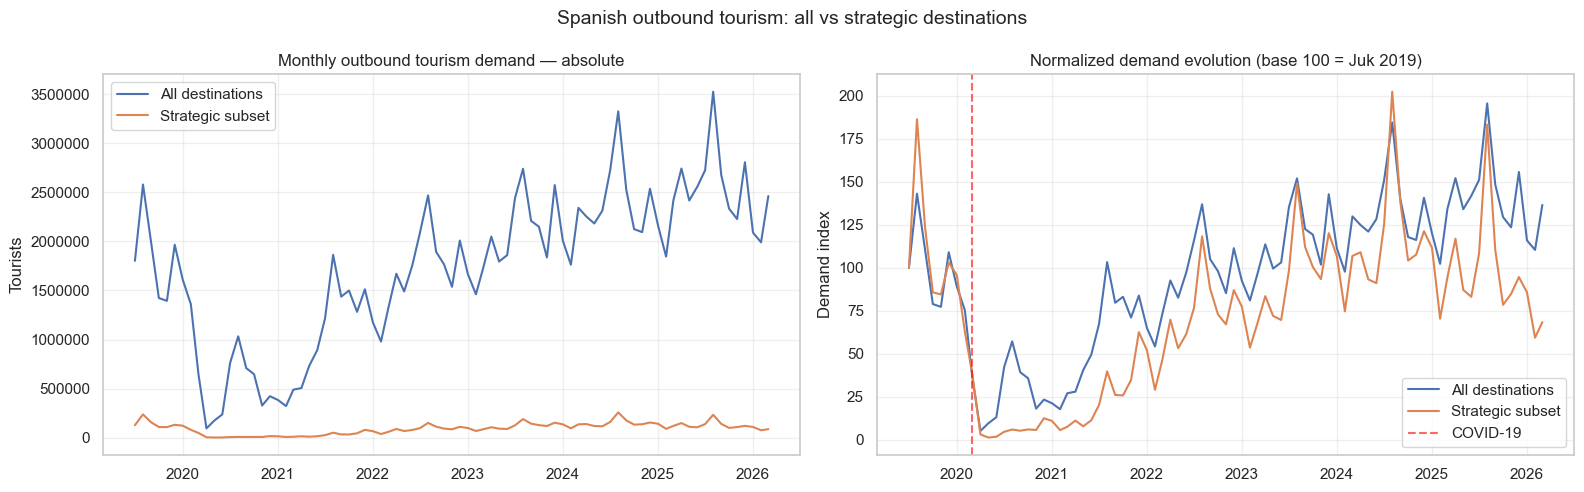

In [74]:
monthly_all = df_spain.groupby("period")["total_tourists"].sum()
monthly_rel = df_non_europe.groupby("period")["total_tourists"].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Absolute
axes[0].plot(monthly_all.index, monthly_all.values, label="All destinations")
axes[0].plot(monthly_rel.index, monthly_rel.values, label="Strategic subset")
axes[0].set_title("Monthly outbound tourism demand — absolute")
axes[0].set_ylabel("Tourists")
axes[0].ticklabel_format(style="plain", axis="y")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Normalized
monthly_all_idx = (monthly_all / monthly_all.iloc[0]) * 100
monthly_rel_idx = (monthly_rel / monthly_rel.iloc[0]) * 100

axes[1].plot(monthly_all_idx.index, monthly_all_idx.values, label="All destinations")
axes[1].plot(monthly_rel_idx.index, monthly_rel_idx.values, label="Strategic subset")
axes[1].axvline(pd.Timestamp("2020-03-01"), linestyle="--", color="red", alpha=0.6, label="COVID-19")
axes[1].set_title("Normalized demand evolution (base 100 = Juk 2019)")
axes[1].set_ylabel("Demand index")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Spanish outbound tourism: all vs strategic destinations", fontsize=14)
plt.tight_layout()
plt.show()

After normalizing both series to a common base index, strategic destinations show a structurally different demand evolution than the overall market. 
- In 2020, the long-haul subset suffered a substantially deeper COVID shock, while the total market retained some short-haul European demand throughout the pandemic. 
- During recovery, the strategic subset shows greater volatility and a less stable trajectory, consistent with the higher sensitivity of organized long-haul travel to macroeconomic conditions, international connectivity, airline capacity constraints and traveler confidence.

---

## 6. COVID impact and recovery index

In [75]:
# Filter H2 only (July-December), excluding 2026
df_h2_spain = df_spain[
    (df_spain["period"].dt.month >= 7) &
    (df_spain["year"] < 2026)
]
df_h2_non_europe = df_non_europe[
    (df_non_europe["period"].dt.month >= 7) &
    (df_non_europe["year"] < 2026)
]

# Annual H2 totals
recovery_all       = df_h2_spain.groupby(df_h2_spain["period"].dt.year)["total_tourists"].sum()
recovery_strategic = df_h2_non_europe.groupby(df_h2_non_europe["period"].dt.year)["total_tourists"].sum()

# Normalize to 2019 H2
index_all       = (recovery_all       / recovery_all.loc[2019])       * 100
index_strategic = (recovery_strategic / recovery_strategic.loc[2019]) * 100

print(index_all)
print(index_strategic)

period
2019    100.000000
2020     34.959159
2021     78.958792
2022    105.454217
2023    125.004649
2024    137.396902
2025    146.027549
Name: total_tourists, dtype: float64
period
2019    100.000000
2020      5.950210
2021     30.700263
2022     74.653684
2023     98.613932
2024    117.026688
2025     96.651139
Name: total_tourists, dtype: float64


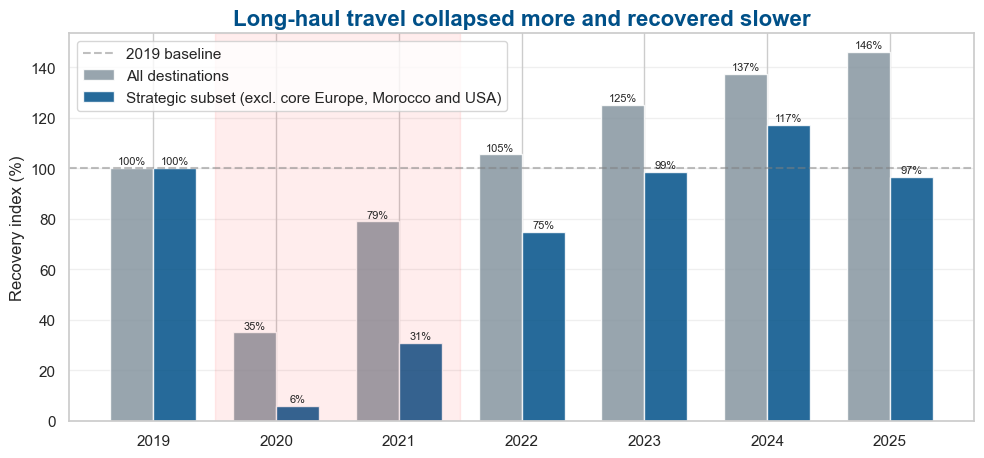

In [76]:
fig, ax = plt.subplots(figsize=(10, 5))

width = 0.35
x = index_all.index

ax.bar(x - width/2, index_all.values, width,
       label="All destinations", color="#8695a0", alpha=0.85)
ax.bar(x + width/2, index_strategic.values, width,
       label="Strategic subset (excl. core Europe, Morocco and USA)", color="#005088", alpha=0.85)

ax.axhline(100, linestyle="--", color="gray", alpha=0.5, label="2019 baseline")
ax.axvspan(2019.5, 2021.5, color="red", alpha=0.07)
ax.set_ylabel("Recovery index (%)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# % above bar
for i, (v_all, v_str) in enumerate(zip(index_all.values, index_strategic.values)):
    ax.text(x[i] - width/2, v_all + 1.5, f"{v_all:.0f}%", ha="center", fontsize=8)
    ax.text(x[i] + width/2, v_str + 1.5, f"{v_str:.0f}%", ha="center", fontsize=8)

plt.title(
    "Long-haul travel collapsed more and recovered slower",
    fontsize=16, fontweight="bold", color="#005088"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



---

### Covid recovery (all destinations vs most touristic countries)

In [77]:
summary_table = pd.DataFrame({
    "All dest. (total trips)":  recovery_all.round(0).astype(int),
    "Strategic (total trips)":  recovery_strategic.round(0).astype(int),
    "All dest. (index)":        index_all.round(1),
    "Strategic (index)":        index_strategic.round(1)
})

display(summary_table.style.format({
    "All dest. (total trips)":  "{:,.0f}",
    "Strategic (total trips)":  "{:,.0f}",
    "All dest. (index)":        "{:.1f}%",
    "Strategic (index)":        "{:.1f}%"
}))

,All dest. (total trips),Strategic (total trips),All dest. (index),Strategic (index)
period,,,,
2019,"11,153,718","870,087",100.0%,100.0%
2020,"3,899,246","51,772",35.0%,6.0%
2021,"8,806,841","267,119",79.0%,30.7%
2022,"11,762,066","649,552",105.5%,74.7%
2023,"13,942,666","858,027",125.0%,98.6%
2024,"15,324,863","1,018,234",137.4%,117.0%
2025,"16,287,501","840,949",146.0%,96.7%


- Long-haul, agency-driven destinations suffered a dramatically deeper COVID shock than the broader market, collapsing to just 6% of 2019 H2 (jul-dec) levels in 2020, compared to 35% for all destinations combined.
- Recovery was also slower: the strategic subset only returned to baseline in 2024, two years after the overall market.

## 7. Top destinations by total demand

---

In [78]:
df_ranked = df_non_europe[df_non_europe["year"] < 2026].groupby(
    ["destination", "year"]
)["total_tourists"].sum().reset_index()

df_ranked["rank"] = df_ranked.groupby("year")["total_tourists"].rank(
    ascending=False, method="min"
).astype(int)

top10_names = (
    df_ranked[df_ranked["year"] == df_ranked["year"].max()]
    .nsmallest(10, "rank")["destination"]
)

df_rank_top10 = df_ranked[df_ranked["destination"].isin(top10_names)]

---

In [79]:
fig = go.Figure()
colors = px.colors.qualitative.Plotly

for i, dest in enumerate(df_rank_top10["destination"].unique()):
    sub = df_rank_top10[df_rank_top10["destination"] == dest].sort_values("year")
    col = colors[i % len(colors)]
    
    # dashed line
    early = sub[sub["year"] <= 2020]
    fig.add_trace(go.Scatter(
        x=early["year"], y=early["rank"],
        mode="lines+markers",
        line=dict(color=col, width=4, dash="dot"),
        marker=dict(size=10, color=col),
        showlegend=False,
        customdata=early[["destination", "total_tourists"]].values,
        hovertemplate="%{customdata[0]}<br>Rank: %{y}<br>Tourists: %{customdata[1]:,.0f}<extra></extra>",
    ))
    
    late = sub[sub["year"] >= 2020]
    fig.add_trace(go.Scatter(
        x=late["year"], y=late["rank"],
        mode="lines+markers",
        line=dict(color=col, width=4),
        marker=dict(size=10, color=col),
        showlegend=False,
        customdata=late[["destination", "total_tourists"]].values,
        hovertemplate="%{customdata[0]}<br>Rank: %{y}<br>Tourists: %{customdata[1]:,.0f}<extra></extra>",
    ))

# H2 annotation
fig.add_vrect(
    x0=2018.5, x1=2019.5,
    fillcolor="gray", opacity=0.08,
    line_width=0,
    annotation_text="    Jul-dec only",
    annotation_position="top left",
    annotation_font=dict(size=12, color="gray"),
)

# Country names (end of each line)
for dest in df_rank_top10["destination"].unique():
    last = df_rank_top10[df_rank_top10["destination"] == dest].iloc[-1]
    fig.add_annotation(
        x=last["year"], y=last["rank"],
        text=dest,
        xanchor="left", xshift=10,
        showarrow=False,
        font=dict(size=11),
    )

fig.update_xaxes(
    tickmode="array",
    range=[2018.5, 2026.5],
    tickvals=sorted(df_rank_top10["year"].unique()),
)
fig.update_yaxes(range=[13.5, 0.5], tickmode="linear", dtick=1)
fig.update_layout(
    title="<b>How COVID reshaped long-haul destination rankings</b>",
    title_font_size=22,
    yaxis_title="Ranking (by total trips)",
    xaxis_title="",
    template="plotly_white",
    height=600,
    margin=dict(r=80),
)

fig.show()

- The United States and Turkey kept positions #1 and #2 throughout the entire period.
- China experienced the most dramatic collapse: from #7 (2019) to #34 (2021) and #51 (2022), driven by China's extended zero-COVID border closures. Recovery was swift back to #7 by 2024.
- Norway dropped from #3 to #10 during COVID (2020) but recovered fully to #3 by 2022 and has held that position since.
- República Dominicana and México show a counter-cyclical COVID pattern: both *improved* their ranking during 2020–2021 (tourists 
  shifted to open Caribbean/Latin American destinations), then declined as traditional routes reopened.
- Argentina shows a sustained upward trend: from #11 (2019) to #5 (2025), suggesting growing structural demand independent of COVID effects.

---

In [80]:
df_rank_top10.pivot(
    index="destination", 
    columns="year", 
    values="rank"
).sort_values(2025)

pivot_rank = df_rank_top10.pivot(index="destination", columns="year", values="rank")
pivot_vol = df_rank_top10.pivot(index="destination", columns="year", values="total_tourists")
pivot_rank["tourists_2019-2025"] = df_rank_top10.groupby("destination")["total_tourists"].sum()

pivot_rank["tourists_2025"] = pivot_vol[2025]
pivot_rank.sort_values(2025, key=lambda x: x).style.format(
    {"tourists_2025": "{:,.0f}"}
).background_gradient(subset=["tourists_2025"], cmap="Blues")


year,2019,2020,2021,2022,2023,2024,2025,tourists_2019-2025,tourists_2025
destination,,,,,,,,,
Estados Unidos de América,1,1,1,1,1,1,1,2599847,"415,104"
Turquía,2,2,2,2,2,2,2,849362,"136,865"
Noruega,3,10,8,3,3,3,3,366822,"91,864"
Colombia,4,3,5,5,5,4,4,290080,"72,088"
Argentina,11,6,9,9,6,6,5,220201,"67,859"
Emiratos Árabes Unidos,5,5,6,7,7,8,6,227129,"65,732"
México,8,7,4,4,4,5,7,276980,"63,861"
República Dominicana,6,4,3,6,9,9,8,246967,"61,842"
China,7,11,34,51,13,7,9,158101,"60,660"


---

In [81]:
def plot_regional_bump_chart(community_name, source_df):
    filtered_df = source_df[
        (source_df['autonomous_community'] == community_name) & 
        (source_df['continent'] != 'Europa') &
        (source_df['destination_clean'] != 'marruecos')
    ].copy()
    
    rank_df = (
        filtered_df
        .groupby(["year", "destination"])["total_tourists"]
        .sum()
        .reset_index()
    )
    rank_df = rank_df[rank_df["year"] < 2026]
    
    rank_df["rank"] = (
        rank_df.groupby("year")["total_tourists"]
        .rank(ascending=False)
        .astype(int)
    )
    
    top10_list = (
        filtered_df
        .groupby("destination")["total_tourists"]
        .sum()
        .nlargest(10)
        .index.tolist()
    )
    
    plot_data = rank_df[rank_df["destination"].isin(top10_list)].copy()
    
    fig = go.Figure()
    colors = px.colors.qualitative.Plotly

    for i, dest in enumerate(plot_data["destination"].unique()):
        sub = plot_data[plot_data["destination"] == dest].sort_values("year")
        col = colors[i % len(colors)]
        
        early = sub[sub["year"] <= 2020]
        fig.add_trace(go.Scatter(
            x=early["year"], y=early["rank"],
            mode="lines+markers",
            line=dict(color=col, width=4, dash="dot"),
            marker=dict(size=10, color=col),
            showlegend=False,
            customdata=early[["destination", "total_tourists"]].values,
            hovertemplate="%{customdata[0]}<br>Rank: %{y}<br>Tourists: %{customdata[1]:,.0f}<extra></extra>",
        ))
        
        late = sub[sub["year"] >= 2020]
        fig.add_trace(go.Scatter(
            x=late["year"], y=late["rank"],
            mode="lines+markers",
            line=dict(color=col, width=4),
            marker=dict(size=10, color=col),
            showlegend=False,
            customdata=late[["destination", "total_tourists"]].values,
            hovertemplate="%{customdata[0]}<br>Rank: %{y}<br>Tourists: %{customdata[1]:,.0f}<extra></extra>",
        ))

    fig.add_vrect(
        x0=2018.5, x1=2019.5,
        fillcolor="gray", opacity=0.08,
        line_width=0,
        annotation_text="      jul-dec only",
        annotation_position="top left",
        annotation_font=dict(size=12, color="gray"),
    )

    for dest in plot_data["destination"].unique():
        last = plot_data[plot_data["destination"] == dest].iloc[-1]
        fig.add_annotation(
            x=last["year"], y=last["rank"],
            text=dest,
            xanchor="left", xshift=10,
            showarrow=False,
            font=dict(size=11),
        )

    fig.update_xaxes(
        tickmode="array",
        range=[2018.5, 2026.8],
        tickvals=sorted(plot_data["year"].unique()),
    )
    
    fig.update_yaxes(range=[13.5, 0.5], tickmode="linear", dtick=1)
    fig.update_layout(
        title=f"<b>How COVID reshaped rankings — {community_name} (excl. Morocco)</b>",
        title_font_size=22,
        yaxis_title="Ranking (by total trips)",
        xaxis_title="",
        template="plotly_white",
        height=600,
        width=1400,
        margin=dict(
        l=70,
        r=250,
        t=80,
        b=50
    )
)

    fig.show()

plot_regional_bump_chart("Cataluña", df_geo_all)
plot_regional_bump_chart("Madrid, Comunidad de", df_geo_all)

---

## 8. Demand by continent

In [82]:
df_continent = (
    df_non_europe[
        (df_non_europe["year"] >= 2022) & 
        (df_non_europe["year"] <= 2025)
    ]
    .groupby(["continent", "destination"])["total_tourists"]
    .sum()
    .reset_index()
)

# Exclude "Other"
df_continent = df_continent[
    ~df_continent["destination"].str.contains("otros", na=False)
]

fig = px.treemap(
    df_continent,
    path=["continent", "destination"],
    values="total_tourists",
    color="total_tourists",
    color_continuous_scale="Blues",
    title="Tourism demand composition by continent and destination",
)

fig.update_layout(
    paper_bgcolor="white",
    plot_bgcolor="white",
    width=1000,
    height=600,
    title_x=0.5,
    title_font=dict(size=16, color="#1B2A4A", family="Arial Black"),
    coloraxis_showscale=False
)


fig.update_traces(
    textinfo="label+percent root",
    textfont=dict(size=13)
)

fig.show()

- America dominates the non europe subset, accounting for over 50% of long-haul demand — largely driven by the United States (35% alone).  
- Asia is the second continent, led by Turkey (12%) and UAE (3%).  
- European destinations in scope (Norway, Finland, Iceland) represent ~9% combined, confirming their niche but stable role in organized long-haul travel from Spain.   
- Africa and Oceania remain marginal markets, although Egypt is a destinations that remains important.

---

#### TABLE FOR ALL DESTINATIONS

In [83]:
# Annual demand by destination
annual = (
    df_non_europe[df_non_europe["year"] < 2026]
    .groupby(["destination", "year"])["total_tourists"]
    .sum()
    .reset_index()
)

# Ranking per year
annual["ranking"] = (
    annual.groupby("year")["total_tourists"]
    .rank(ascending=False, method="min")
    .astype(int)
)

#  YoY variation %
annual = annual.sort_values(["destination", "year"])
annual["yoy_%"] = (
    annual.groupby("destination")["total_tourists"]
    .pct_change() * 100
)

# Share per year (%)
annual["share_%"] = (
    annual.groupby("year")["total_tourists"]
    .transform(lambda x: x / x.sum() * 100)
)

# Top 3 peak months
monthly_demand = (
    df_non_europe[
        (df_non_europe["year"] >= 2022) &
        (df_non_europe["year"] < 2026)
    ]
    .groupby(["destination", "month"])["total_tourists"]
    .sum()
    .reset_index()
)

month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

top3_months = (
    monthly_demand
    .sort_values(["destination", "total_tourists"], ascending=[True, False])
    .groupby("destination")
    .head(3)
    .groupby("destination")["month"]
    .apply(lambda x: ", ".join(x.map(month_names)))
    .rename("top_3_months")
)


seasonality_cv = (
    df_non_europe[
        (df_non_europe["year"] >= 2022) &
        (df_non_europe["year"] < 2026)
    ]
    .groupby("destination")["total_tourists"]
    .agg(["mean", "std"])
)
seasonality_cv["seasonality_cv"] = (
    seasonality_cv["std"] / seasonality_cv["mean"]
)
seasonality_cv = seasonality_cv["seasonality_cv"]


signals = (
    df_non_europe
    .groupby("destination")
    .agg(
        monthly_searches_avg=("monthly_searches", "mean"),
        trend_index_avg=("trend_index", "mean"),
    )
)

def safe_corr(group):
    ms = group["monthly_searches"]
    tt = group["total_tourists"]
    if ms.notna().sum() >= 4 and ms.std() > 0 and tt.std() > 0:
        return ms.corr(tt)
    return np.nan

corr_ms = (
    df_non_europe
    .groupby("destination")
    .apply(safe_corr, include_groups=False)
    .rename("corr_searches")
)


continent = (
    df_non_europe
    .groupby("destination")["continent"]
    .first()
)


df_summary = (
    annual
    .merge(continent, on="destination", how="left")
    .merge(top3_months, on="destination", how="left")
    .merge(seasonality_cv, on="destination", how="left")
    .merge(signals, on="destination", how="left")
    .merge(corr_ms, on="destination", how="left")
)

df_summary = df_summary[[
    "destination", "continent", "year", "total_tourists",
    "ranking", "share_%", "yoy_%",
    "top_3_months", "seasonality_cv",
    "monthly_searches_avg", "trend_index_avg", "corr_searches"
]]


latest_year = df_summary["year"].max()

display_df = (
    df_summary[df_summary["year"] == latest_year]
    .sort_values("ranking")
    .head(20)
    .reset_index(drop=True)
)

styled = (
    display_df.style
    .format({
        "total_tourists": "{:,.0f}",
        "ranking": "{:.0f}",
        "share_%": "{:.1f}%",
        "yoy_%": "{:+.1f}%",
        "seasonality_cv": "{:.2f}",
        "monthly_searches_avg": "{:,.0f}",
        "trend_index_avg": "{:.1f}",
        "corr_searches": "{:+.3f}",
    }, na_rep="—")
    .background_gradient(subset=["corr_searches"], cmap="RdYlGn", vmin=-1, vmax=1)
    .background_gradient(subset=["seasonality_cv"], cmap="YlOrRd", vmin=0, vmax=2)
    .set_caption(f"Destination intelligence summary — top 20 strategic markets ({latest_year})")
)

display(styled)

# Export for Streamlit
df_summary.to_parquet(
    Path("../data/processed/08_destination_summary.parquet"),
    index=False
)
print(f"\nExported: 08_destination_summary.parquet  ({df_summary.shape})")
print(f"Showing: top 20 for {latest_year} · Full table has all years x destinations")

,destination,continent,year,total_tourists,ranking,share_%,yoy_%,top_3_months,seasonality_cv,monthly_searches_avg,trend_index_avg,corr_searches
0,Estados Unidos de América,America,2025,"415,104",1,26.6%,-34.4%,"Aug, Sep, Dec",0.31,"4,751",6.9,-0.429
1,Turquía,Asia,2025,"136,865",2,8.8%,-36.5%,"Aug, Oct, Sep",0.31,"9,475",20.8,+0.475
2,Noruega,Europa,2025,"91,864",3,5.9%,-7.9%,"Aug, Jul, Sep",0.83,"10,992",9.1,+0.122
3,Colombia,America,2025,"72,088",4,4.6%,+4.2%,"Aug, Dec, Jan",0.40,"3,014",38.9,+0.708
4,Argentina,America,2025,"67,859",5,4.4%,+26.4%,"Dec, Jan, Nov",0.63,"3,395",10.9,+0.597
5,Emiratos Árabes Unidos,Asia,2025,"65,732",6,4.2%,+41.9%,"Nov, Jan, Apr",0.45,"4,177",7.6,+0.429
6,México,America,2025,"63,861",7,4.1%,-0.2%,"Aug, Jul, Jan",0.38,"3,805",41.3,+0.203
7,República Dominicana,America,2025,"61,842",8,4.0%,+37.8%,"Aug, Jul, Jan",0.52,"4,714",17.6,+0.530
8,China,Asia,2025,"60,660",9,3.9%,+29.8%,"Aug, Jul, Nov",0.82,"2,591",13.9,+0.832
9,Japón,Asia,2025,"47,933",10,3.1%,+15.0%,"Aug, Sep, Jul",0.88,"4,403",46.6,+0.621



Exported: 08_destination_summary.parquet  ((635, 12))
Showing: top 20 for 2025 · Full table has all years x destinations


#### TABLE FOR STRATEGIC SUBSET

In [84]:
# Annual demand by destination
annual = (
    df_commercial[df_commercial["year"] < 2026]
    .groupby(["destination", "year"])["total_tourists"]
    .sum()
    .reset_index()
)

# Ranking per year
annual["ranking"] = (
    annual.groupby("year")["total_tourists"]
    .rank(ascending=False, method="min")
    .astype(int)
)

#  YoY variation %
annual = annual.sort_values(["destination", "year"])
annual["yoy_%"] = (
    annual.groupby("destination")["total_tourists"]
    .pct_change() * 100
)

# Share per year (%)
annual["share_%"] = (
    annual.groupby("year")["total_tourists"]
    .transform(lambda x: x / x.sum() * 100)
)

# Top 3 peak months
monthly_demand = (
    df_commercial[
        (df_commercial["year"] >= 2022) &
        (df_commercial["year"] < 2026)
    ]
    .groupby(["destination", "month"])["total_tourists"]
    .sum()
    .reset_index()
)

month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

top3_months = (
    monthly_demand
    .sort_values(["destination", "total_tourists"], ascending=[True, False])
    .groupby("destination")
    .head(3)
    .groupby("destination")["month"]
    .apply(lambda x: ", ".join(x.map(month_names)))
    .rename("top_3_months")
)


seasonality_cv = (
    df_commercial[
        (df_commercial["year"] >= 2022) &
        (df_commercial["year"] < 2026)
    ]
    .groupby("destination")["total_tourists"]
    .agg(["mean", "std"])
)
seasonality_cv["seasonality_cv"] = (
    seasonality_cv["std"] / seasonality_cv["mean"]
)
seasonality_cv = seasonality_cv["seasonality_cv"]


signals = (
    df_commercial
    .groupby("destination")
    .agg(
        monthly_searches_avg=("monthly_searches", "mean"),
        trend_index_avg=("trend_index", "mean"),
    )
)

def safe_corr(group):
    ms = group["monthly_searches"]
    tt = group["total_tourists"]
    if ms.notna().sum() >= 4 and ms.std() > 0 and tt.std() > 0:
        return ms.corr(tt)
    return np.nan

corr_ms = (
    df_commercial
    .groupby("destination")
    .apply(safe_corr, include_groups=False)
    .rename("corr_searches")
)


continent = (
    df_commercial
    .groupby("destination")["continent"]
    .first()
)


df_summary = (
    annual
    .merge(continent, on="destination", how="left")
    .merge(top3_months, on="destination", how="left")
    .merge(seasonality_cv, on="destination", how="left")
    .merge(signals, on="destination", how="left")
    .merge(corr_ms, on="destination", how="left")
)

df_summary = df_summary[[
    "destination", "continent", "year", "total_tourists",
    "ranking", "share_%", "yoy_%",
    "top_3_months", "seasonality_cv",
    "monthly_searches_avg", "trend_index_avg", "corr_searches"
]]


latest_year = df_summary["year"].max()

display_df = (
    df_summary[df_summary["year"] == latest_year]
    .sort_values("ranking")
    .head(20)
    .reset_index(drop=True)
)

styled = (
    display_df.style
    .format({
        "total_tourists": "{:,.0f}",
        "ranking": "{:.0f}",
        "share_%": "{:.1f}%",
        "yoy_%": "{:+.1f}%",
        "seasonality_cv": "{:.2f}",
        "monthly_searches_avg": "{:,.0f}",
        "trend_index_avg": "{:.1f}",
        "corr_searches": "{:+.3f}",
    }, na_rep="—")
    .background_gradient(subset=["corr_searches"], cmap="RdYlGn", vmin=-1, vmax=1)
    .background_gradient(subset=["seasonality_cv"], cmap="YlOrRd", vmin=0, vmax=2)
    .set_caption(f"Destination intelligence summary — top 20 strategic markets ({latest_year})")
)

display(styled)

# Export for Streamlit
df_summary.to_parquet(
    Path("../data/processed/08_destination_summary_strategic_subset.parquet"),
    index=False
)
print(f"\nExported: 08_destination_summary_strategic_subset.parquet  ({df_summary.shape})")
print(f"Showing: top 20 for {latest_year} · Full table has all years x destinations")

,destination,continent,year,total_tourists,ranking,share_%,yoy_%,top_3_months,seasonality_cv,monthly_searches_avg,trend_index_avg,corr_searches
0,Estados Unidos de América,America,2025,"415,104",1,29.0%,-34.4%,"Aug, Sep, Dec",0.31,"4,751",6.9,-0.429
1,Turquía,Asia,2025,"136,865",2,9.6%,-36.5%,"Aug, Oct, Sep",0.31,"9,475",20.8,+0.475
2,Noruega,Europa,2025,"91,864",3,6.4%,-7.9%,"Aug, Jul, Sep",0.83,"10,992",9.1,+0.122
3,Colombia,America,2025,"72,088",4,5.0%,+4.2%,"Aug, Dec, Jan",0.40,"3,014",38.9,+0.708
4,Argentina,America,2025,"67,859",5,4.7%,+26.4%,"Dec, Jan, Nov",0.63,"3,395",10.9,+0.597
5,Emiratos Árabes Unidos,Asia,2025,"65,732",6,4.6%,+41.9%,"Nov, Jan, Apr",0.45,"4,177",7.6,+0.429
6,México,America,2025,"63,861",7,4.5%,-0.2%,"Aug, Jul, Jan",0.38,"3,805",41.3,+0.203
7,República Dominicana,America,2025,"61,842",8,4.3%,+37.8%,"Aug, Jul, Jan",0.52,"4,714",17.6,+0.530
8,China,Asia,2025,"60,660",9,4.2%,+29.8%,"Aug, Jul, Nov",0.82,"2,591",13.9,+0.832
9,Japón,Asia,2025,"47,933",10,3.4%,+15.0%,"Aug, Sep, Jul",0.88,"4,403",46.6,+0.621



Exported: 08_destination_summary_strategic_subset.parquet  ((310, 12))
Showing: top 20 for 2025 · Full table has all years x destinations


---

## 9. Seasonality:

In [85]:
monthly_share = (
    df_commercial[
        (df_commercial["year"] >= 2022) &
        (df_commercial["year"] < 2026)
    ]
    .groupby(["destination", "month"])["total_tourists"]
    .sum()
    .reset_index()
)

monthly_share["share"] = (
    monthly_share.groupby("destination")["total_tourists"]
    .transform(lambda x: x / x.sum() * 100)
)

pivot = monthly_share.pivot(
    index="destination",
    columns="month",
    values="share"
).fillna(0)


continent_map = (
    df_commercial[["destination", "continent"]]
    .drop_duplicates()
    .set_index("destination")["continent"]
)

pivot["continent"] = pivot.index.map(continent_map)
pivot["cv"] = pivot.iloc[:, :12].std(axis=1) / pivot.iloc[:, :12].mean(axis=1)


pivot = pivot.sort_values(["continent", "cv"], ascending=[True, False])


pivot_plot = pivot.drop(columns=["continent", "cv"])


month_names = {1:"January",2:"February",3:"March",4:"April",5:"May",6:"June",
               7:"July",8:"August",9:"September",10:"October",11:"November",12:"December"}
pivot_plot.columns = [month_names[c] for c in pivot_plot.columns]


continent_labels = pivot["continent"]
breaks = [i for i in range(1, len(continent_labels))
          if continent_labels.iloc[i] != continent_labels.iloc[i-1]]
break_positions = [0] + breaks + [len(continent_labels)]
continent_names = [continent_labels.iloc[p] for p in break_positions[:-1]]

fig = px.imshow(
    pivot_plot,
    color_continuous_scale="YlOrRd",
    aspect="auto",
    title="<b>Seasonal demand distribution — long-haul agency destinations (2023-2025)</b>",
    labels=dict(color="% of annual demand"),
    zmin=0, zmax=46,
)

for b in breaks:
    fig.add_hline(y=b - 0.5, line_color="white", line_width=3)

for i, (pos_start, pos_end, name) in enumerate(
    zip(break_positions[:-1], break_positions[1:], continent_names)
):
    mid = (pos_start + pos_end - 1) / 2
    fig.add_annotation(
        x=-0.5,
        y=mid,
        text=f"<b>{name}</b>",
        showarrow=False,
        xref="x",
        yref="y",
        xanchor="right",
        font=dict(size=10, color="#1B2A4A"),
    )

fig.update_layout(
    height=1000,
    template="plotly_white",
    title_font_size=16,
    coloraxis_colorbar=dict(title="% annual"),
    xaxis_title="",
    yaxis_title="",
    margin=dict(l=160),
)

fig.show()

---

## 10. Top-5 destination time series

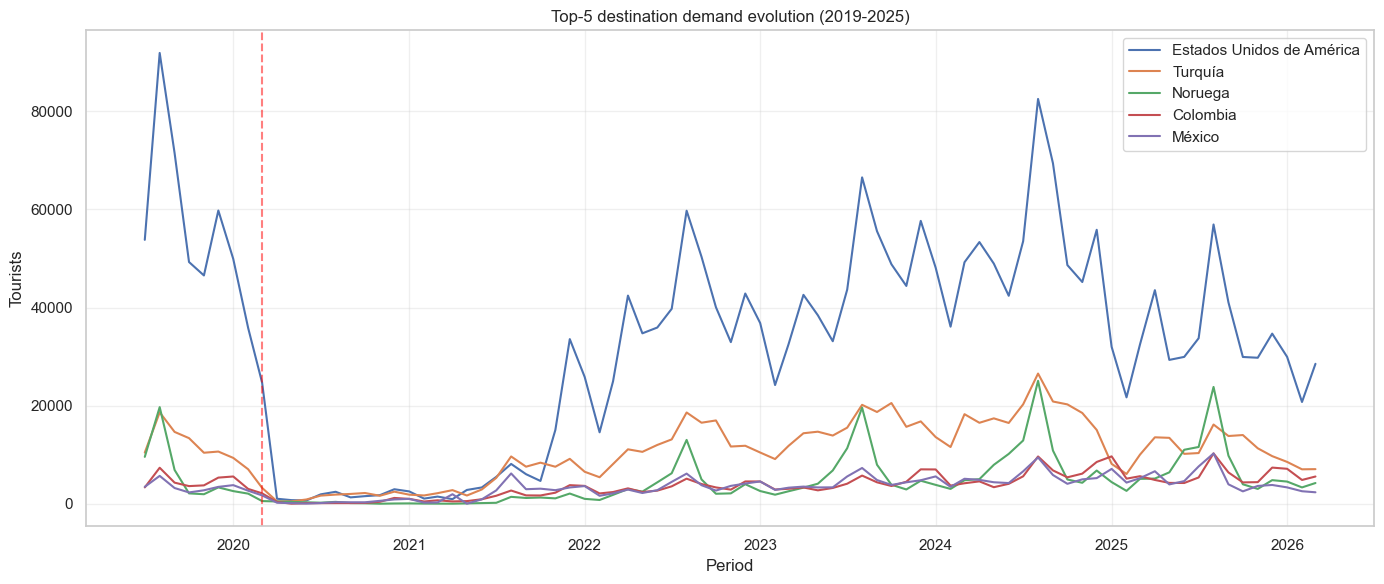

In [86]:
top_5 = (
    df_non_europe[
        (df_non_europe["year"] < 2026)
    ]
    .groupby("destination")["total_tourists"]
    .sum().sort_values(ascending=False).head(5).index
)

plt.figure(figsize=(14, 6))

for country in top_5:
    temp = (
        df_non_europe[df_non_europe["destination"] == country]
        .groupby("period")["total_tourists"]
        .sum()
    )
    plt.plot(temp.index, temp.values, label=country)

plt.axvline(pd.Timestamp("2020-03-01"), linestyle="--", color="red", alpha=0.5)
plt.title("Top-5 destination demand evolution (2019-2025)")
plt.xlabel("Period")
plt.ylabel("Tourists")
plt.ticklabel_format(style="plain", axis="y")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The top-5 destinations show structurally different recovery patterns.  
- **USA and Turkey** recovered to pre-COVID levels by 2022 and continued growing — the most resilient markets in the strategic subset.  
- **Norway** shows a sharp COVID dip but full recovery by 2022, reflecting its sensitivity to long-haul travel restrictions.  
- **Colombia** maintained relative stability across the full period, with a more moderate COVID shock — consistent with a high VFR component cushioning demand.  

---
# PART B — Digital Signal Evaluation

## 11. Signal quality — zero-value structure

Before evaluating correlations, it is important to understand the structural quality of each signal. A signal with many zero values is structurally sparse and will produce artificially weak correlations regardless of actual demand behavior.

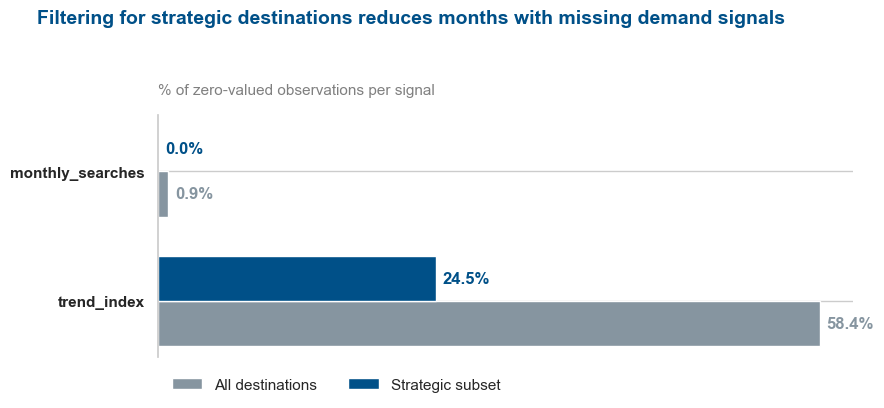

In [87]:

paises_estrategicos = df_commercial["destination_clean"].unique()
df_trends_strat = df_trends_agg[df_trends_agg["country"].isin(paises_estrategicos)]
df_searches_strat = df_monthly_searches_agg[df_monthly_searches_agg["country"].isin(paises_estrategicos)]


signals = ["trend_index", "monthly_searches"]

all_dests = [
    (df_trends_agg["trend_index"] == 0).mean() * 100,
    (df_monthly_searches_agg["monthly_searches"] == 0).mean() * 100
]

strat_dests = [
    (df_trends_strat["trend_index"] == 0).mean() * 100,
    (df_searches_strat["monthly_searches"] == 0).mean() * 100
]


y = np.arange(len(signals))
height = 0.35

fig, ax = plt.subplots(figsize=(9, 4))

bars_all = ax.barh(y - height/2, all_dests, height, label="All destinations", color="#8695a0")
bars_strat = ax.barh(y + height/2, strat_dests, height, label="Strategic subset", color="#005088")


ax.bar_label(bars_all, fmt='%.1f%%', padding=5, color="#8695a0", fontweight="bold")
ax.bar_label(bars_strat, fmt='%.1f%%', padding=5, color="#005088", fontweight="bold")


ax.set_yticks(y)
ax.set_yticklabels(signals, fontweight="bold")


plt.suptitle("Filtering for strategic destinations reduces months with missing demand signals", 
             x=0.05, y=1.05, ha="left", fontsize=14, fontweight="bold", color="#005088")
ax.set_title("% of zero-valued observations per signal", 
             loc="left", fontsize=11, color="gray", pad=15)

# Remove chart junk (borders and X-axis)
ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.get_xaxis().set_visible(False) 

# Legend setup
ax.legend(loc="lower left", bbox_to_anchor=(0, -0.2), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

> **Key finding:**
ALL DESTINATIONS SET: Google Trends produces ~60% zero-valued observations after country-level aggregation. This is a structural limitation of the relative normalization methodology — when benchmark queries have very high volume, smaller destinations are compressed to zero despite real search activity existing. DataForSEO produces near-zero sparsity. This difference **directly explains** why GT correlations are noisier throughout the analysis.  

>Filtering for strategic destinations reduces months with missing demand signals data.

## 12. Signal distributions — KDE comparison

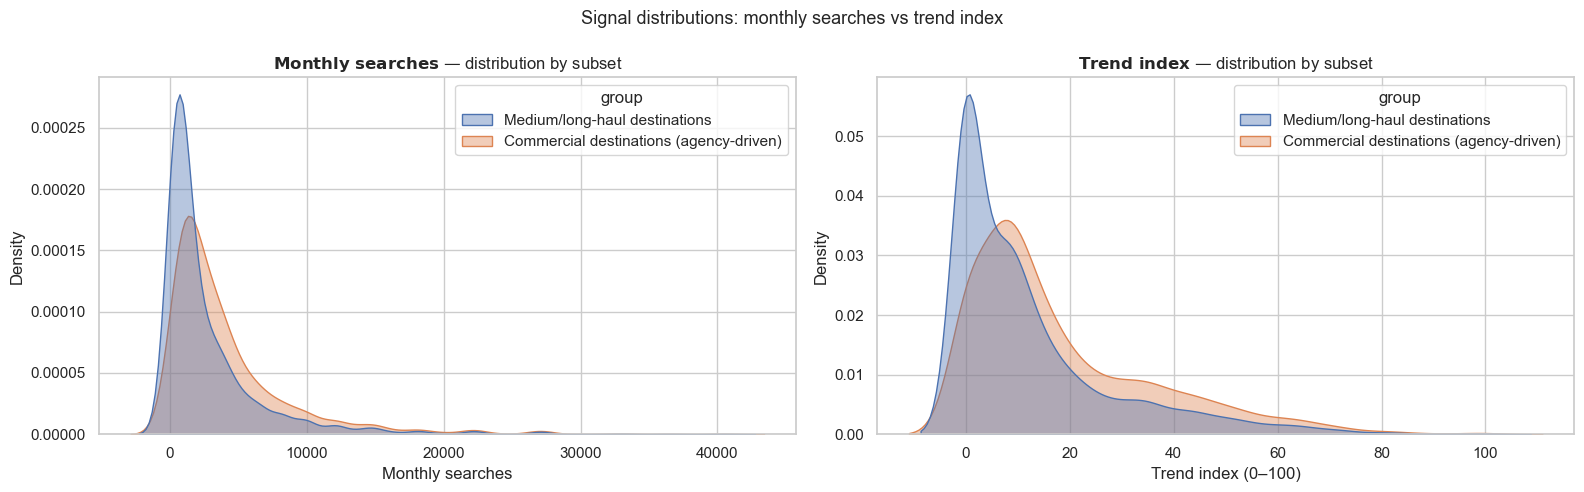

In [88]:
df_non_europe_grp = df_non_europe.copy()
df_non_europe_grp["group"] = "Medium/long-haul destinations"

df_commercial_grp = df_commercial.copy()
df_commercial_grp["group"] = "Commercial destinations (agency-driven)"

comparison_df = pd.concat([df_non_europe_grp, df_commercial_grp], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.kdeplot(
    data=comparison_df, x="monthly_searches",
    hue="group", fill=True, common_norm=False,
    alpha=0.4, ax=axes[0]
)
axes[0].set_title(r"$\bf{Monthly\ searches}$ — distribution by subset")
axes[0].set_xlabel("Monthly searches")

sns.kdeplot(
    data=comparison_df, x="trend_index",
    hue="group", fill=True, common_norm=False,
    alpha=0.4, ax=axes[1]
)
axes[1].set_title(r"$\bf{Trend\ index}$ — distribution by subset")
axes[1].set_xlabel("Trend index (0–100)")

plt.suptitle("Signal distributions: monthly searches vs trend index", fontsize=13)
plt.tight_layout()
plt.show()

Both signals are strongly right-skewed. Monthly searches preserve greater absolute dispersion across destinations. The commercial subset shifts toward higher search volumes, which confirms that agency-mediated destinations attract systematically higher search volumes.

## 13. Search demand vs tourism demand — scatterplots

Spearman r = 0.431
p-value = 0.0000


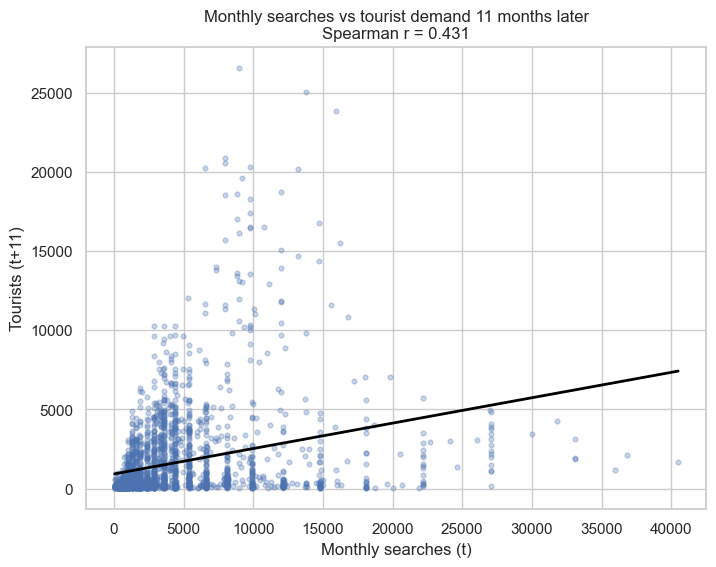

In [ ]:


# Lag 11 months
df_lag11 = df_commercial_no_usa.copy()

df_lag11 = df_lag11.sort_values(
    ["destination", "period"]
)

df_lag11["future_tourists"] = (
    df_lag11
    .groupby("destination")["total_tourists"]
    .shift(-11)
)

df_plot = df_lag11[
    ["monthly_searches", "future_tourists"]
].dropna()

# Spearman
spearman_r, p_value = stats.spearmanr(
    df_plot["monthly_searches"],
    df_plot["future_tourists"]
)

print(f"Spearman r = {spearman_r:.3f}")
print(f"p-value = {p_value:.4f}")

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    df_plot["monthly_searches"],
    df_plot["future_tourists"],
    alpha=0.3,
    s=12
)

# Linear trendline (visual aid only)
m, b = np.polyfit(
    df_plot["monthly_searches"],
    df_plot["future_tourists"],
    1
)

x_line = np.linspace(
    df_plot["monthly_searches"].min(),
    df_plot["monthly_searches"].max(),
    100
)

plt.plot(
    x_line,
    m*x_line + b,
    color="black",
    linewidth=2
)

plt.title(
    f"Monthly searches vs tourist demand 11 months later\nSpearman r = {spearman_r:.3f}"
)

plt.xlabel("Monthly searches (t)")
plt.ylabel("Tourists (t+11)")
plt.show()

## 14. General Correlation analysis

**Business question:** Does digital search activity explain tourism demand equally well across all destinations?

Destination-level correlations identify markets with strong predictive digital behavior vs. weak or noise-dominated relationships.

In [90]:
tourists_all = df_commercial["total_tourists"].dropna()
searches_all = df_commercial["monthly_searches"].dropna()
trend_all = df_commercial["trend_index"].dropna()

stat_t, p_t = stats.shapiro(tourists_all)
stat_s, p_s = stats.shapiro(searches_all)
stat_tr, p_tr = stats.shapiro(trend_all)

print(f"total_tourists  — Shapiro W={stat_t:.4f}, p={p_t:.65f}")
print(f"monthly_searches — Shapiro W={stat_s:.4f}, p={p_s:.60f}")
print(f"trend_index — Shapiro W={stat_tr:.4f}, p={p_tr:.50f}")
print()
print(f"total_tourists:   {'Normal (p>0.05)' if p_t > 0.05 else 'NO normal (p≤0.05)'}")
print(f"monthly_searches: {'Normal (p>0.05)' if p_s > 0.05 else 'NO normal (p≤0.05)'}")
print(f"trend_index: {'Normal (p>0.05)' if p_tr > 0.05 else 'NO normal (p≤0.05)'}")

total_tourists  — Shapiro W=0.3319, p=0.00000000000000000000000000000000000000000000000000000000000000000
monthly_searches — Shapiro W=0.7117, p=0.000000000000000000000000000000000000000000000000000000002227
trend_index — Shapiro W=0.8568, p=0.00000000000000000000000000000000000000000000147534

total_tourists:   NO normal (p≤0.05)
monthly_searches: NO normal (p≤0.05)
trend_index: NO normal (p≤0.05)


#### Conclusion after Shapiro - Wilk test: 

>**Correlation method must be Spearman instead of Pearson**

Before computing correlations, we tested whether the key variables follow a normal distribution, a requirement for Pearson correlation to be valid. A normal distribution means values cluster symmetrically around an average.

Tourism data has not behaved this way. A small number of destinations attract the vast majority of travelers, while most destinations have low volumes. This creates a heavily skewed distribution, not symmetric.

Shapiro-Wilk normality tests confirm this formally:

| Variable | Shapiro-Wilk W | p-value | Result |
|---|---|---|---|
| total_tourists | 0.332 | ≈ 0 | Not normal |
| monthly_searches | 0.711 | ≈ 0 | Not normal |
| trend_index | 0.857 | ≈ 0 | Not normal |

A p-value close to zero means it is statistically impossible that 
these variables follow a normal distribution.

**Spearman rank correlation is therefore used throughout this analysis.**
Instead of comparing raw values where a single large market like the United States could dominate the result, Spearman compares the relative ordering of values (rankings).

In [91]:
def compute_country_correlations(df, signal_col, label):
    """
    Per-destination Spearman correlation between signal and total_tourists.
    Returns correlation, p-value, and significance flag.
    Minimum 12 valid observations required per destination.
    """
    results = []
    for dest in df["destination"].unique():
        subset = df[df["destination"] == dest]
        valid = subset[[signal_col, "total_tourists"]].dropna()
        if len(valid) >= 12:
            corr, p_value = stats.spearmanr(valid[signal_col], valid["total_tourists"])
            results.append({
                "destination": dest,
                "correlation": corr,
                "p_value": p_value,
                "significant": p_value < 0.05,
                "n_obs": len(valid),
            })
    corr_df = pd.DataFrame(results)
    corr_df["signal"] = label
    return corr_df

#### Correlations month with same month / commercial subset / 2022-2025 period (excluding COVID 2020-2021)

>**Raw signals work before you start applying time shifts**

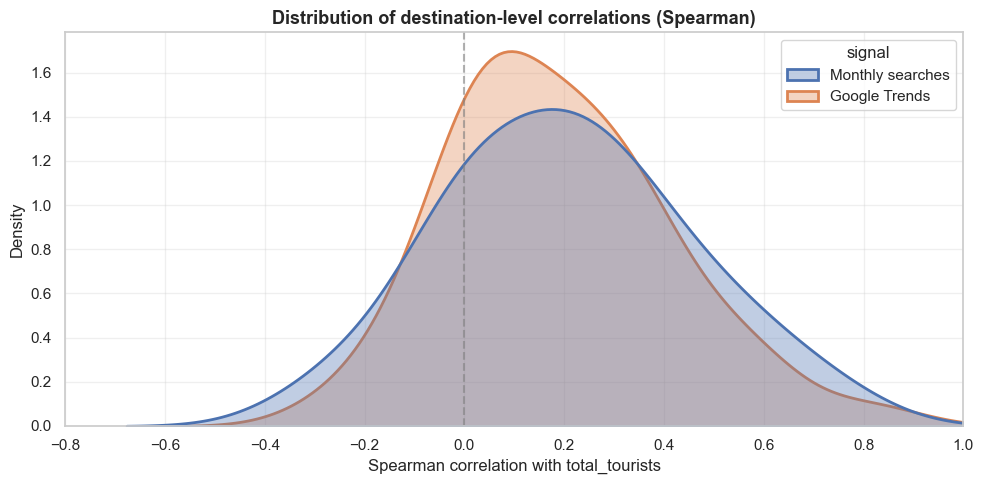

Valid destinations per signal:
signal
Google Trends       44
Monthly searches    45

Monthly searches:
  Total destinations:               45
  Statistically significant (p<0.05): 18 (40.0%)
  Significant AND positive:         18 (40.0%)

Google Trends:
  Total destinations:               46
  Statistically significant (p<0.05): 14 (30.4%)
  Significant AND positive:         14 (30.4%)
Monthly searches median: 0.187
Google Trends median:    0.176
Monthly searches % positive: 77.8%
Google Trends % positive:    78.3%
Total valid correlations: 89
Destinations (monthly_searches): 45
Destinations (trend_index):      44


In [92]:

df_corr_base = df_commercial[
    ~df_commercial["year"].between(2020, 2021)
]

monthly_corr = compute_country_correlations(df_corr_base, "monthly_searches", "Monthly searches")
trends_corr  = compute_country_correlations(df_corr_base, "trend_index",       "Google Trends")

corr_combined = pd.concat([monthly_corr, trends_corr], ignore_index=True)

plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=corr_combined, x="correlation", hue="signal",
    fill=True, common_norm=False, alpha=0.35, linewidth=2
)
plt.axvline(0, linestyle="--", color="gray", alpha=0.6)
plt.title("Distribution of destination-level correlations (Spearman)", fontsize=13, fontweight="bold")
plt.xlabel("Spearman correlation with total_tourists")
plt.xlim(-0.8, 1.0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

corr_combined = corr_combined.dropna(subset=["correlation"])
print("Valid destinations per signal:")
print(corr_combined.groupby("signal")["destination"].count().to_string())

# Statistical significance summary
for name, df_corr in [("Monthly searches", monthly_corr), ("Google Trends", trends_corr)]:
    n_total = len(df_corr)
    n_sig = df_corr["significant"].sum()
    n_sig_pos = ((df_corr["significant"]) & (df_corr["correlation"] > 0)).sum()
    print(f"\n{name}:")
    print(f"  Total destinations:               {n_total}")
    print(f"  Statistically significant (p<0.05): {n_sig} ({n_sig/n_total:.1%})")
    print(f"  Significant AND positive:         {n_sig_pos} ({n_sig_pos/n_total:.1%})")
    
print(f"Monthly searches median: {monthly_corr['correlation'].median():.3f}")
print(f"Google Trends median:    {trends_corr['correlation'].median():.3f}")
print(f"Monthly searches % positive: {(monthly_corr['correlation'] > 0).mean():.1%}")
print(f"Google Trends % positive:    {(trends_corr['correlation'] > 0).mean():.1%}")
print(f"Total valid correlations: {len(corr_combined.dropna())}")
print(f"Destinations (monthly_searches): {monthly_corr.dropna()['destination'].nunique()}")
print(f"Destinations (trend_index):      {trends_corr.dropna()['destination'].nunique()}")

Restricting the analysis to the 46 commercial destinations (excl. COVID 2020–2021) shows moderate but consistent positive correlations between digital signals and tourism demand.

| Metric | Monthly searches | Google Trends |
|---|---|---|
| Mean Spearman r | 0.204 | 0.188 |
| Median Spearman r | 0.187 | 0.176 |
| % positive correlations | 77.8% | 78.3% |

Both signals perform similarly. The lower values compared to Pearson reflect Spearman's rank-based approach, which is more conservative and robust to the extreme volume differences across destinations (USA: ~400K tourists vs Kirguistán: ~1K).

> **Validation:** For  USA, Pearson r = -0.152 vs Spearman r = -0.054. Pearson amplifies extreme values, producing more negative results than warranted. Spearman gives a more conservative and methodologically correct estimate, particularly important in a dataset where destination volumes span three orders of magnitude.

45 destinations had sufficient data (≥12 observations) for valid Spearman correlation estimates.

## 15. Lag analysis

**Business question:** Do search signals *lead* tourism demand, or do they behave as contemporaneous signals?

> **Methodological note:** The lag analysis below computes aggregate correlations across all destinations combined. This approach has a known limitation: it may mask destination-level heterogeneity (optimal lag for Japan may differ from Morocco). Results should be interpreted as structural average behavior, not as per-destination leading indicators.


### 15.1 Lag by destination

In [93]:
df_no_covid = df_commercial[
    ~df_commercial["year"].between(2020, 2021)
].copy()

lag_searches = find_optimal_lag(
    df_no_covid,
    "monthly_searches"
)

lag_trends = find_optimal_lag(
    df_no_covid,
    "trend_index"
)

In [94]:
def find_optimal_lag(df, signal_col, max_lag=11, min_obs=12):
    """Find optimal lag per destination using Spearman correlation."""    
    results = []
    for dest in df["destination"].unique():
        sub = df[df["destination"] == dest].sort_values("period")
        if len(sub) < min_obs:
            continue
        best_lag, best_corr = 0, -999
        for lag in range(0, max_lag + 1):
            lagged = sub[signal_col].shift(lag)
            valid = pd.DataFrame({
                "signal": lagged,
                "tourists": sub["total_tourists"]
            }).dropna()
            if len(valid) < 24:
                continue
            corr, _ = stats.spearmanr(valid["signal"], valid["tourists"])
            if pd.notna(corr) and corr > best_corr:
                best_corr = corr
                best_lag = lag
        results.append({
            "destination": dest,
            f"optimal_lag_{signal_col}": best_lag,
            f"max_corr_{signal_col}": round(best_corr, 3),
        })
    return pd.DataFrame(results)

lag_searches = find_optimal_lag(df_no_covid, "monthly_searches")
lag_trends   = find_optimal_lag(df_no_covid, "trend_index")

lag_table = lag_searches.merge(lag_trends, on="destination")
continent = df_commercial_no_usa.groupby("destination")["continent"].first()
lag_table = lag_table.merge(continent, on="destination")
lag_table = lag_table.sort_values("optimal_lag_monthly_searches", ascending=False)

display(
    lag_table.style
    .background_gradient(
        subset=["optimal_lag_monthly_searches", "optimal_lag_trend_index"],
        cmap="YlOrRd"
    )
    .background_gradient(
        subset=["max_corr_monthly_searches", "max_corr_trend_index"],
        cmap="RdYlGn", vmin=-1, vmax=1
    )
    .format({
        "max_corr_monthly_searches": "{:+.3f}",
        "max_corr_trend_index":      "{:+.3f}",
    })
)

,destination,optimal_lag_monthly_searches,max_corr_monthly_searches,optimal_lag_trend_index,max_corr_trend_index,continent
2,Australia,11,+0.070,11,+0.173,Oceania
18,India,11,+0.266,0,+0.173,Asia
7,Chile,10,-0.110,2,+0.139,America
26,Noruega,8,+0.799,8,+0.596,Europa
24,Maldivas,7,+0.327,7,+0.311,Asia
9,Colombia,7,+0.542,7,+0.523,America
32,Sudáfrica,7,+0.214,7,-0.034,Africa
31,Sri Lanka,6,+0.581,6,+0.562,Asia
41,Nepal,6,+0.421,1,+0.126,Asia
39,Vietnam,6,+0.564,7,+0.419,Asia


In [95]:
def compute_destination_lags(df, signal_col, max_lag=11, min_obs=12):
    """Compute Spearman correlation at each lag (0 to max_lag) per destination."""    
    results = []
    for dest in df["destination"].unique():
        sub = df[df["destination"] == dest].sort_values("period")
        if len(sub) < min_obs:
            continue
        for lag in range(0, max_lag + 1):
            lagged = sub[signal_col].shift(lag)
            valid = pd.DataFrame({
                "signal": lagged,
                "tourists": sub["total_tourists"]
            }).dropna()
            if len(valid) < 6:
                corr = np.nan
            else:
                corr, _ = stats.spearmanr(valid["signal"], valid["tourists"])
            results.append({
                "destination": dest,
                "lag": lag,
                "correlation": round(corr, 3) if pd.notna(corr) else np.nan,
                "signal": signal_col,
            })
    return pd.DataFrame(results)

>The optimal search lead time varies significantly across destinations, ranging from 0 to 11 months. No single lag dominates, confirming that a uniform advance booking assumption would be methodologically incorrect.  
Nepal, Cabo Verde and Chile show optimal lags close to 11 months

---
#### Simplified heatmap: lags (0, 3, 6, 9, 11) excluding 2020-2021
max_lag=11: lag 12 excluded to avoid seasonal autocorrelation artifact

In [ ]:
df_no_covid = df_commercial[
    ~df_commercial["year"].between(2020, 2021)
]

lags_heat = compute_destination_lags(df_no_covid, "monthly_searches", max_lag=11)


strategic_lags = [0, 3, 6, 9, 11]
pivot_lag = (
    lags_heat[lags_heat["lag"].isin(strategic_lags)]
    .pivot(index="destination", columns="lag", values="correlation")
)
pivot_lag.columns = [f"lag_{c}m" for c in pivot_lag.columns]


continent = df_commercial.groupby("destination")["continent"].first()
pivot_lag = pivot_lag.merge(continent, on="destination")

pivot_lag["optimal_lag"] = (
    pivot_lag.filter(like="lag_")
    .idxmax(axis=1, skipna=True)
    .str.extract(r"(\d+)")
    .squeeze()
    .astype(float)
    .astype("Int64")
)

pivot_lag = pivot_lag.sort_values(
    ["continent", "optimal_lag"], ascending=[True, False]
)


fig = px.imshow(
    pivot_lag.filter(like="lag_"),
    color_continuous_scale="RdYlGn",
    color_continuous_midpoint=0,
    aspect="auto",
    zmin=-0.8, zmax=0.8,
    title="<b>Search-demand correlation at strategic lag windows (excl. COVID 2020-2021)</b>",
    labels=dict(color="Spearman"),
    text_auto=".2f",
)

fig.update_layout(
    height=700,
    template="plotly_white",
    title_font_size=16,
    xaxis_title="Lag (months)",
    yaxis_title="",
    coloraxis_colorbar=dict(title="Spearman"),
    margin=dict(l=160),
)

fig.update_xaxes(
    tickvals=list(range(len(strategic_lags))),
    ticktext=[f"lag {l}m" for l in strategic_lags],
)

fig.update_traces(textfont=dict(size=9))

fig.show()

In [97]:
# Scatter: lag òptim vs correlació màxima (excl. COVID 2020-2021)

df_no_covid = df_commercial_no_usa[
    ~df_commercial_no_usa["year"].between(2020, 2021)
]

lags_scatter = compute_destination_lags(df_no_covid, "monthly_searches", max_lag=11)

# Lag òptim i correlació màxima per destinació
scatter_df = (
    lags_scatter
    .dropna(subset=["correlation"])
    .sort_values("correlation", ascending=False)
    .groupby("destination")
    .first()
    .reset_index()
    [["destination", "lag", "correlation"]]
    .rename(columns={"lag": "optimal_lag", "correlation": "max_corr"})
)

scatter_df = scatter_df.merge(
    df_commercial_no_usa.groupby("destination")["continent"].first(),
    on="destination"
)


fig = px.scatter(
    scatter_df,
    x="optimal_lag",
    y="max_corr",
    color="continent",
    text="destination",
    hover_data={"optimal_lag": True, "max_corr": ":.3f", "continent": True},
    title="<b>Optimal search lead time vs maximum correlation (excl. COVID 2020–2021)</b>",
    labels={
        "optimal_lag": "Optimal lag (months)",
        "max_corr": "Maximum correlation (Pearson r)",
        "continent": "Continent",
    },
    template="plotly_white",
)

fig.update_traces(
    textposition="top center",
    textfont=dict(size=9),
    marker=dict(size=10),
)

fig.update_layout(
    height=600,
    title_font_size=16,
    xaxis=dict(dtick=1, range=[-0.5, 14]),
    yaxis=dict(range=[0, 1]),
    margin=dict(t=60),
)


fig.add_hline(
    y=0.8,
    line_dash="dot",
    line_color="gray",
    annotation_text="r = 0.8 (useful threshold)",
    annotation_position="right",
    annotation_font=dict(size=10, color="gray"),
)


fig.add_vline(
    x=12,
    line_dash="dot",
    line_color="gray",
    annotation_text="12m (annual contract)",
    annotation_position="top",
    annotation_font=dict(size=10, color="gray"),
)

fig.show()

#### Distribution of correlations at the 11-month planning horizon
 pivot_lag is created in the heatmap cell above

In [106]:

if "pivot_lag" in dir() and "lag_11m" in pivot_lag.columns:

    df_lag11 = (
        pivot_lag[["lag_11m"]]
        .reset_index()
        .rename(columns={"lag_11m": "corr_11m"})
        .dropna()
        .sort_values("corr_11m", ascending=True)
    )


    df_lag11["signal_strength"] = pd.cut(
        df_lag11["corr_11m"],
        bins=[-1, 0, 0.3, 0.5, 1],
        labels=[
            "Negative",
            "Weak (0-0.3)",
            "Moderate (0.3-0.5)",
            "Strong (>0.5)"
        ]
    )

    fig = px.bar(
        df_lag11,
        x="corr_11m",
        y="destination",
        orientation="h",
        color="signal_strength",
        text="corr_11m",
        color_discrete_map={
            "Negative": "#D85A30",
            "Weak (0-0.3)": "#FAC775",
            "Moderate (0.3-0.5)": "#85B7EB",
            "Strong (>0.5)": "#185FA5",
        },
        labels={
            "corr_11m": "Spearman correlation (11-month lag)",
            "destination": ""
        },
        template="plotly_white",
    )


    fig.add_vline(
        x=0,
        line_dash="solid",
        line_color="gray",
        line_width=1
    )

    fig.add_vline(
        x=0.3,
        line_dash="dot",
        line_color="#85B7EB",
        annotation_text="Moderate (0.3)",
        annotation_position="top right"
    )

    fig.add_vline(
        x=0.5,
        line_dash="dot",
        line_color="#29F570",
        annotation_text="Strong (0.5)",
        annotation_position="top right"
    )

    fig.update_traces(
        texttemplate="%{text:.2f}",
        textposition="outside"        
    )

    fig.update_layout(
        height=max(900, len(df_lag11) * 22),
        margin=dict(l=10, r=40, t=80, b=40),
        legend_title="Signal strength",
        title=dict(
        text="<b>Low correlation at lag 11 across 45 strategic destinations</b><br>",
        font=dict(size=26, color='#2C3E50'), 
        x=0.10,
        y=0.95
        ),
    )
    fig.update_xaxes(
        range=[-1.0, 1.0], 
        tickmode='array',
        tickvals=[-1.0, -0.5, 0, 0.5, 1.0],
        showgrid=True,
        gridcolor='#E5E5E5',
        showline=True,     
        linewidth=1,       
        linecolor='gray', 
        mirror=True,
        tickfont=dict(size=18)    
    )
    

    fig.update_yaxes(
        automargin=True,
        categoryorder="total ascending",
        showline=True,     
        linewidth=1,
        linecolor='gray',
        mirror=True  
    )

    fig.add_vrect(
        x0=0.5, x1=1.0,
        fillcolor="#185FA5", 
        opacity=0.08,        
        layer="below",       
        line_width=0        
    )

    fig.add_annotation(
        x=0.75, y=0.50,
        yref="paper",      
        text="<b>IDEAL RESULT</b><br>TO FORECAST",
        showarrow=False,
        font=dict(color="#030202", size=14),
        opacity=0.8
    )



    fig.show()

    print(
        f"\nDestinations with r > 0.3 at lag 11m: "
        f"{(df_lag11['corr_11m'] > 0.3).sum()}"
    )

    print(
        f"Destinations with r > 0.5 at lag 11m: "
        f"{(df_lag11['corr_11m'] > 0.5).sum()}"
    )

    print(
        f"Destinations with negative r at lag 11m: "
        f"{(df_lag11['corr_11m'] < 0).sum()}"
    )
    

else:
    print("pivot_lag not available — run the heatmap cell first.")


Destinations with r > 0.3 at lag 11m: 6
Destinations with r > 0.5 at lag 11m: 0
Destinations with negative r at lag 11m: 14


**Conclusions**: At an 11-month lead time, only 6 of 45 commercial destinations (~13%) show a Spearman correlation above 0.3.
Anual seat allocation cannot be partially informed by digital signals for this narrow set of destinations. 
Digital signals are not proven as a universal forecasting tool within these framework and data.

## 16. Annual correlation stability — violin plots

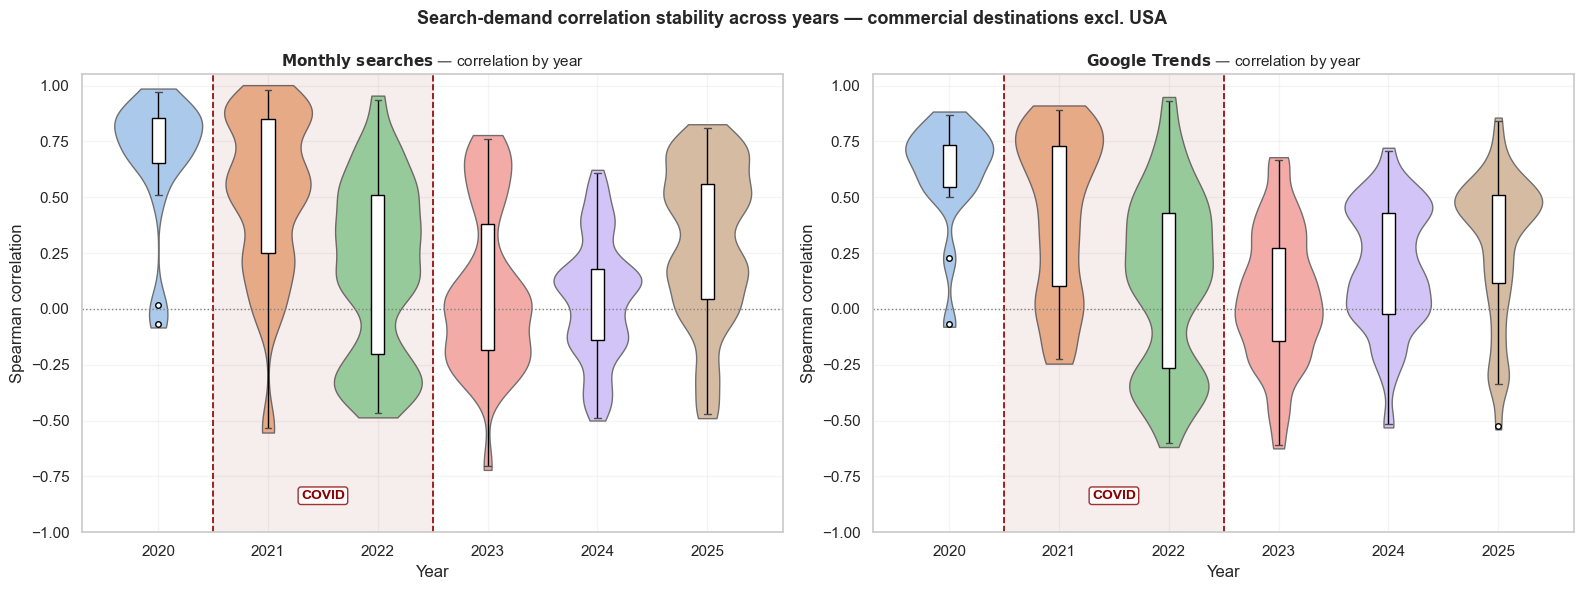

In [104]:
def compute_annual_correlations(df, signal_col):
    """Compute per-destination, per-year Spearman correlations. Excludes constant series."""
    valid_groups = (
        df.groupby(["year", "destination"])
        .filter(
            lambda x:
            len(x) >= 8 and
            x[signal_col].nunique() > 1 and
            x["total_tourists"].nunique() > 1
        )
    )

    def spearman_corr(x):
        valid = x[[signal_col, "total_tourists"]].dropna()
        if len(valid) < 2:
            return np.nan
        corr, _ = stats.spearmanr(valid[signal_col], valid["total_tourists"])
        return corr

    return (
        valid_groups
        .groupby(["year", "destination"])
        .apply(spearman_corr, include_groups=False)
        .reset_index(name="correlation")
    )


monthly_by_year = compute_annual_correlations(df_commercial_no_usa, "monthly_searches")
trends_by_year  = compute_annual_correlations(df_commercial_no_usa, "trend_index")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, df_corr, title in [
    (axes[0], monthly_by_year, r"$\bf{Monthly\ searches}$ — correlation by year"),
    (axes[1], trends_by_year,  r"$\bf{Google\ Trends}$ — correlation by year")
]:
    sns.violinplot(
        data=df_corr, x="year", y="correlation",
        hue="year", legend=False, inner=None,
        cut=0.2, linewidth=1, palette="pastel",
        bw_adjust=0.5, ax=ax
    )
    sns.boxplot(
        data=df_corr, x="year", y="correlation",
        width=0.12, showcaps=True, showfliers=True,
        boxprops={"facecolor": "white", "edgecolor": "black", "zorder": 10},
        medianprops={"color": "darkred", "linewidth": 2},
        whiskerprops={"color": "black"},
        flierprops={"marker": "o", "markerfacecolor": "white",
                    "markeredgecolor": "black", "markersize": 4,
                    "zorder": 11},
        ax=ax
    )
    ax.axvspan(0.5, 2.5, color="darkred", alpha=0.07)
    ax.axvline(0.5, color="darkred", linestyle="--", linewidth=1.2)
    ax.axvline(2.5, color="darkred", linestyle="--", linewidth=1.2)
    ax.text(1.5, -0.85, "COVID", ha="center", color="darkred",
            fontweight="bold", fontsize=10,
            bbox=dict(facecolor="white", edgecolor="darkred",
                      alpha=0.8, boxstyle="round,pad=0.2"))
    ax.axhline(0, color="gray", linestyle=":", linewidth=1)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Year")
    ax.set_ylabel("Spearman correlation")
    ax.set_ylim(-1, 1.05)
    ax.grid(alpha=0.2)

plt.suptitle(
    "Search-demand correlation stability across years — commercial destinations excl. USA",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

The sharp spike in 2020–2021 does not mean the signals improved. When both search activity and tourism collapsed at the same time due to COVID, they moved together by coincidence, not because one predicted the other.

The post-2022 period is more meaningful: correlations stabilized at moderate positive levels (0.1–0.3), with the commercial subset consistently above the broader dataset.

## 17. Evolution of mean correlations across subsets

In [100]:
def yearly_mean_correlations(df, subset_name):
    """Compute mean destination-level Spearman correlation per year, for both signals."""
    results = []
    for year in sorted(df["year"].dropna().unique()):
        if year >= 2026:
            continue
        temp_year = df[df["year"] == year]
        for signal_col, signal_label in [
            ("monthly_searches", "Monthly searches"),
            ("trend_index",      "Google Trends")
        ]:
            corr_values = []
            for dest in temp_year["destination"].unique():
                temp_dest = temp_year[temp_year["destination"] == dest]
                valid = temp_dest[[signal_col, "total_tourists"]].dropna()
                if len(valid) >= 4 and valid[signal_col].nunique() > 1:
                    corr, _ = stats.spearmanr(valid[signal_col], valid["total_tourists"])
                    if pd.notna(corr):
                        corr_values.append(corr)
            if corr_values:
                results.append({
                    "year": year,
                    "mean_correlation": np.mean(corr_values),
                    "signal": signal_label,
                    "subset": subset_name,
                })
    return pd.DataFrame(results)

# Compute across subsets
yearly_results = pd.concat([
    yearly_mean_correlations(df_spain,              "All destinations"),
    yearly_mean_correlations(df_non_europe,         "World without Europe"),
    yearly_mean_correlations(df_commercial,         "Commercial no EU"),
    yearly_mean_correlations(df_commercial_no_usa,  "Commercial no EU/USA"),
], ignore_index=True)

fig = px.line(
    yearly_results,
    x="year", y="mean_correlation",
    color="subset", facet_col="signal",
    markers=True,
    title="Evolution of mean Spearman correlations across tourism subsets",
    template="plotly_white",
    labels={"mean_correlation": "Mean Spearman correlation", "subset": "Dataset subset"}
)
fig.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.5)
fig.add_vrect(x0=2019.5, x1=2021.5, fillcolor="red", opacity=0.06,
              annotation_text="COVID", annotation_position="top left",
              annotation_font=dict(size=10, color="red"))
fig.update_layout(width=1200, height=500, title_x=0.5, hovermode="x unified")
fig.update_yaxes(range=[-1, 1])
fig.show()

Post-COVID correlations (2022–2024) remained low and flat across all subsets. However, 2025 shows a recovery in correlation strength, particularly for the commercial subset excluding USA, suggesting that search signals could be gaining predictive value as travel patterns normalize.

**The commercial subset consistently outperforms the broader dataset, validating the agency_profile filter.**

---
# PART C — Methodological Limitations & Conclusions

## 18. Methodological limitations

### 1. Relative normalization bias (Google Trends)
GT normalized indices are relative, not absolute. When benchmark queries have very high volume, smaller destinations are compressed to zero despite real search activity. This explains ~60% zero-value rate and systematically weaker GT correlations.

### 2. Single-prefix search query design
The `"viaje a"` prefix captures organized/agency-mediated intent. It structurally underrepresents short-haul European destinations where independent search behavior dominates (`"vuelos a"`, `"hotel en"`). This creates a deliberate but documented asymmetry with the full INE dataset. However, search behavior may not be adequately captured by the selected query structure.

### 3. Geographic aggregation mismatch
Search signals were collected at destination country level. This masks regional heterogeneity (e.g., a traveler searching "viaje a Bangkok" contributes to Thailand demand but may not reach the aggregated country signal meaningfully).

### 4. Structural tourism heterogeneity
The dataset combines leisure tourism, VFR travel, diaspora mobility, business travel and niche destinations. These have fundamentally different digital search behaviors. Aggregating them dilutes the signal.

### 5. INE dataset experimental limitations
The INE mobility dataset is based on SIM card positioning, not traveler surveys. It includes cross-border commuting, eSIM artifacts and airport-mode gaps. This introduces structural noise independent of search behavior.

### 6. Lag analysis aggregation limitation
Lag analysis above is computed as an aggregate across all destinations. Destination-level heterogeneity in optimal lag is masked. A Japan traveler may plan 6 months ahead; a Morocco traveler 3 weeks ahead. Future work should evaluate per-destination lag structures individually.

### 7. Multilingual search behavior

Travelers may search using diferent destination names, other terms or travel-related queries not captured by the selected keyword architecture. Also, queries in other official languages in Spain have not been included and should be considered important (Catalan, Gallego, Euskera, etc)

## 19. Summary statistics

In [101]:
# Summary uses monthly_corr and trends_corr from cell 69
# These are Spearman correlations on df_commercial, excl. COVID 2020-2021

summary = pd.DataFrame({
    "metric": ["Mean", "Median", "Std", "% Positive"],
    "Monthly searches": [
        monthly_corr["correlation"].mean(),
        monthly_corr["correlation"].median(),
        monthly_corr["correlation"].std(),
        (monthly_corr["correlation"] > 0).mean()
    ],
    "Google Trends": [
        trends_corr["correlation"].mean(),
        trends_corr["correlation"].median(),
        trends_corr["correlation"].std(),
        (trends_corr["correlation"] > 0).mean()
    ],
})

display(
    summary.style
    .format({
        "Monthly searches": lambda x: f"{x:.3f}" if isinstance(x, float) else x,
        "Google Trends":    lambda x: f"{x:.3f}" if isinstance(x, float) else x,
    })
    .set_caption("Spearman correlation summary — commercial subset (excl. COVID 2020–2021)")
    .hide(axis="index")
)

metric,Monthly searches,Google Trends
Mean,0.204,0.188
Median,0.187,0.176
Std,0.250,0.221
% Positive,0.778,0.783


In [102]:
# Executive summary table
def build_executive_summary():
    n_dest = monthly_corr["destination"].nunique()
    
    summary_data = {
        "Question": [
            "How many destinations analyzed?",
            "Are search signals correlated with tourism demand?",
            "Which signal performs better?",
            "Are correlations statistically significant?",
            "What is the optimal forecasting horizon?",
            "Can search signals replace official data?",
        ],
        "Answer": [
            f"{n_dest} commercial destinations (medium/high agency profile)",
            f"Yes, weakly. Median Spearman r = {monthly_corr['correlation'].median():.2f}",
            f"Monthly searches (DataForSEO) outperforms Google Trends due to ~60% zero values in GT",
            f"{monthly_corr['significant'].sum()}/{n_dest} destinations show p < 0.05 in monthly searches",
            f"1–3 months. Signals are predominantly concurrent, not predictive at 11+ months",
            "No. Search signals are a complement, not a substitute for INE mobility data",
        ],
    }
    
    return pd.DataFrame(summary_data)

exec_summary = build_executive_summary()
display(
    exec_summary.style
    .set_caption("Executive Summary — Key Findings")
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "padding": "8px",
        "border": "1px solid #ddd",
    })
)

Question,Answer
How many destinations analyzed?,45 commercial destinations (medium/high agency profile)
Are search signals correlated with tourism demand?,"Yes, weakly. Median Spearman r = 0.19"
Which signal performs better?,Monthly searches (DataForSEO) outperforms Google Trends due to ~60% zero values in GT
Are correlations statistically significant?,18/45 destinations show p < 0.05 in monthly searches
What is the optimal forecasting horizon?,"1–3 months. Signals are predominantly concurrent, not predictive at 11+ months"
Can search signals replace official data?,"No. Search signals are a complement, not a substitute for INE mobility data"


## 20. Final conclusions

### Main findings

1. **Monthly search volumes consistently outperform Google Trends** across all analytical dimensions: lower sparsity, more stable distributions, higher median correlations, better cross-destination differentiation.

2. **Google Trends structural sparsity (~60% zeros) is the primary driver of its weaker performance** — not absence of signal per se, but signal compression due to relative normalization methodology.

3. **Weak-to-moderate correlations are observed under a simplified search-query architecture.** Neither signal appears strong enough to be used as a standalone forecasting tool. Future research should explore alternative keyword designs and richer behavioral signals.

4. **Commercially relevant destinations produce stronger and more stable relationships** supporting the methodological relevance of the `agency_profile` filter.

5. **Lag analyses do not reveal a consistently dominant predictive lead structure**. Search behavior appears highly destination-dependent and largely contemporaneous, with no stable planning horizon emerging across markets.

6. The simplified "viaje a +destination" query structure may not fully capture actual traveler search behavior and remains an important source of uncertainty in digital demand signal extraction.

7. **COVID period correlations are artificially inflated** by synchronized demand collapse. Post-pandemic correlations are more structurally informative.

8. **Several factors may contribute to the weak correlations observed throughout the analysis**, including the experimental nature of the mobility dataset, simplified keyword selection, multilingual search behavior, heterogeneous travel motivations and destination-specific planning horizons.

### Strategic interpretation

Digital search signals should be treated as **complementary behavioral indicators** within broader tourism intelligence frameworks — not as standalone forecasting variables. Their usefulness depends strongly on:
- market maturity and commercial relevance,
- tourism segment homogeneity,
- signal extraction methodology,
- and contextual modeling design.

### Methodological considerations

Several factors may contribute to the weak correlations observed throughout this analysis:

- experimental nature of the mobility dataset,
- simplified keyword selection strategy,
- multilingual search behavior,
- destination-specific planning horizons,
- heterogeneous traveler motivations.

Therefore, weak correlations should not be interpreted as evidence that digital demand signals lack predictive value. Rather, they suggest that the relationship between search behavior and tourism demand is more complex than initially hypothesized and may require more sophisticated signal extraction and modeling approaches.

### Next steps

Future iterations should evaluate alternative search-query architectures, including multilingual keyword sets, travel-oriented destination queries, thematic travel searches and booking-related search behavior, to determine whether stronger digital demand signals can be extracted.

Subsequent modeling stages should integrate search signals together with:

- lagged tourism demand,
- rolling statistical features,
- seasonal indicators and calendar effects,
- transport connectivity variables,
- macroeconomic context,
- alternative keyword architectures (including multilingual and booking-oriented searches)

Hybrid forecasting architectures are likely to produce substantially more robust predictive performance than digital search signals alone.

---

## References

### Primary data sources

- **Instituto Nacional de Estadística (INE).** *Experimental Statistics — 
  Tourism Mobility from Mobile Phone Data*. 2019–2025. 
  https://www.ine.es/experimental/movilidad/experimental_em.htm
  https://www.ine.es/experimental/turismo_moviles/experimental_turismo_moviles.htm

- **Instituto Nacional de Estadística (INE).** *Encuesta de Turismo de 
  Residentes (ETR) — Annual detailed results*. 2019–2025. 
  https://www.ine.es/dyngs/INEbase/operacion.htm?c=Estadistica_C&cid=1254736176990

- **U.S. National Travel & Tourism Office (NTTO).** *Survey of International 
  Air Travelers (SIAT) — Spain Profile*. 2024. 
  https://www.trade.gov/data-visualization/spain-arrivals-country

### Digital signals

- **DataForSEO.** *Google Ads Search Volume API Documentation*. 
  https://docs.dataforseo.com/v3/keywords_data/google_ads/search_volume/

- **PyTrends — Unofficial Google Trends API.** 
  https://github.com/GeneralMills/pytrends

### Methodological foundations

- **Choi, H. & Varian, H.** (2012). *Predicting the Present with Google Trends*. 
  Economic Record, 88(s1), 2–9.

- **Önder, I.** (2017). *Forecasting tourism demand with Google Trends: 
  Accuracy comparison of countries versus cities*. International Journal of 
  Tourism Research, 19(6), 648–660.

- **Yang, X., Pan, B., Evans, J. A., & Lv, B.** (2015). *Forecasting Chinese 
  tourist volume with search engine data*. Tourism Management, 46, 386–397.